In [2]:
import math
import random
import pandas as pd
import numpy as np
import scipy as sp
from scipy import stats
import itertools
from itertools import combinations
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import gridspec
from matplotlib import cm
import matplotlib 
%matplotlib inline

In [3]:
# data from https://docs.google.com/spreadsheets/d/100QgXtkE5FHj-EFaa64HkjYu8EddSB07/edit#gid=1566829729

# cell line IDs
clIDs = ['AACC', 'AAGG', 'ACAC', 'ACCT', 'ACGA', 'ACTG', 'AGAG', 'AGCA', 'AGGT', 'AGTC', 'ATCG', 'ATGC', 'CAAC', 'CACT', 'CAGA', 'CATG', 'CCAA', 'CCTT', 'CGAT', 'CGTA', 'CTGT', 'CTTC', 'GAAG', 'GATC', 'GCAT', 'GCTA', 'GGAA', 'GGTT', 'GTAC', 'GTGA', 'GTTG', 'TCCA', 'TGAC', 'TGCT', 'TGTG', 'TTCC', 'TTGG']

# cell lines; added numbers (1 and 2) to cell lines w/ identical names
cell_lines = ['mT4-2D', '7160c2', 'FC1199', '6694c2', '7160c5', 'BF857', 'BF1987', 'Panc2', '0688_M', 'FC1245-1', 'BF4326-1', 'BF2117', '6419c5', 'BF4326-2', 'UN-KPC_960-1', '0755_Pancreas', 'BF1836', 'BF2014', 'BF5960', '6499c4', '6422c5', 'FC1245-2', 'KPC_cell_line', 'Spike-in1', 'UN-KPC_960-2', 'BF2153', 'UN-KC-6141', 'mT3-2D', 'mT5-2D', '0764_Pancreas', '6421c2', '0755_Ascites', '2838c3', 'Spike-in2', 'Spike-in3', 'FC1242', 'UN-KPC_961']

clID_dict = dict(zip(clIDs, cell_lines))
cell_line_dict = dict(zip(cell_lines, clIDs))

# samples sequenced in the second run
samples_pre_inj = ['SK1_' + '{:0.0f}'.format(i) for i in [61, 62, 63]]
samples_3w = ['SK1_' + '{:0.0f}'.format(i) for i in range(1, 8)] + ['SK1_10'] + ['SK1_' + '{:0.0f}'.format(i) for i in range(12, 45)]
samples_2d = ['SK1_' + '{:0.0f}'.format(i) for i in [45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60]] + ['SK1_58_2', 'SK1_59_2', 'SK1_60_2']
samples_in_vitro = ['SK1_' + '{:0.0f}'.format(i) for i in [64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87]]
samples_transplant = ['SK1_' + '{:0.0f}'.format(i) for i in [94, 95, 99] + [103, 104, 107] + [111, 112, 114]]


In [4]:
! pwd
! ls ../Data/cell-line-level

with open('../Data/cell-line-level/stats_paths.txt') as f:
    paths = [x.strip('\n') for x in f.readlines()]

/Users/alyulina/Projects/Cancer/Code
2-day           in-vitro        reads_stats.png transplant
3-week          pre-inj         stats_paths.txt


In [5]:
stats = [] # order follows that in the stats files, normalized by the total # of reads, i.e.

# frac. of reads that had a regex match and a high q-score but did not pair well
# frac. of reads that passed qc but no clID match
# frac. of reafs that passed qc and had a known clID


for i in paths:
    with open(i) as f:
        lines_i = f.readlines()
    stats_i = [int(lines_i[0].split()[-1])] + [int(x.split()[-1]) / int(lines_i[0].split()[-1]) for x in lines_i[1:]]
    stats.append([i.split('/')[-1][:-24]] + stats_i)

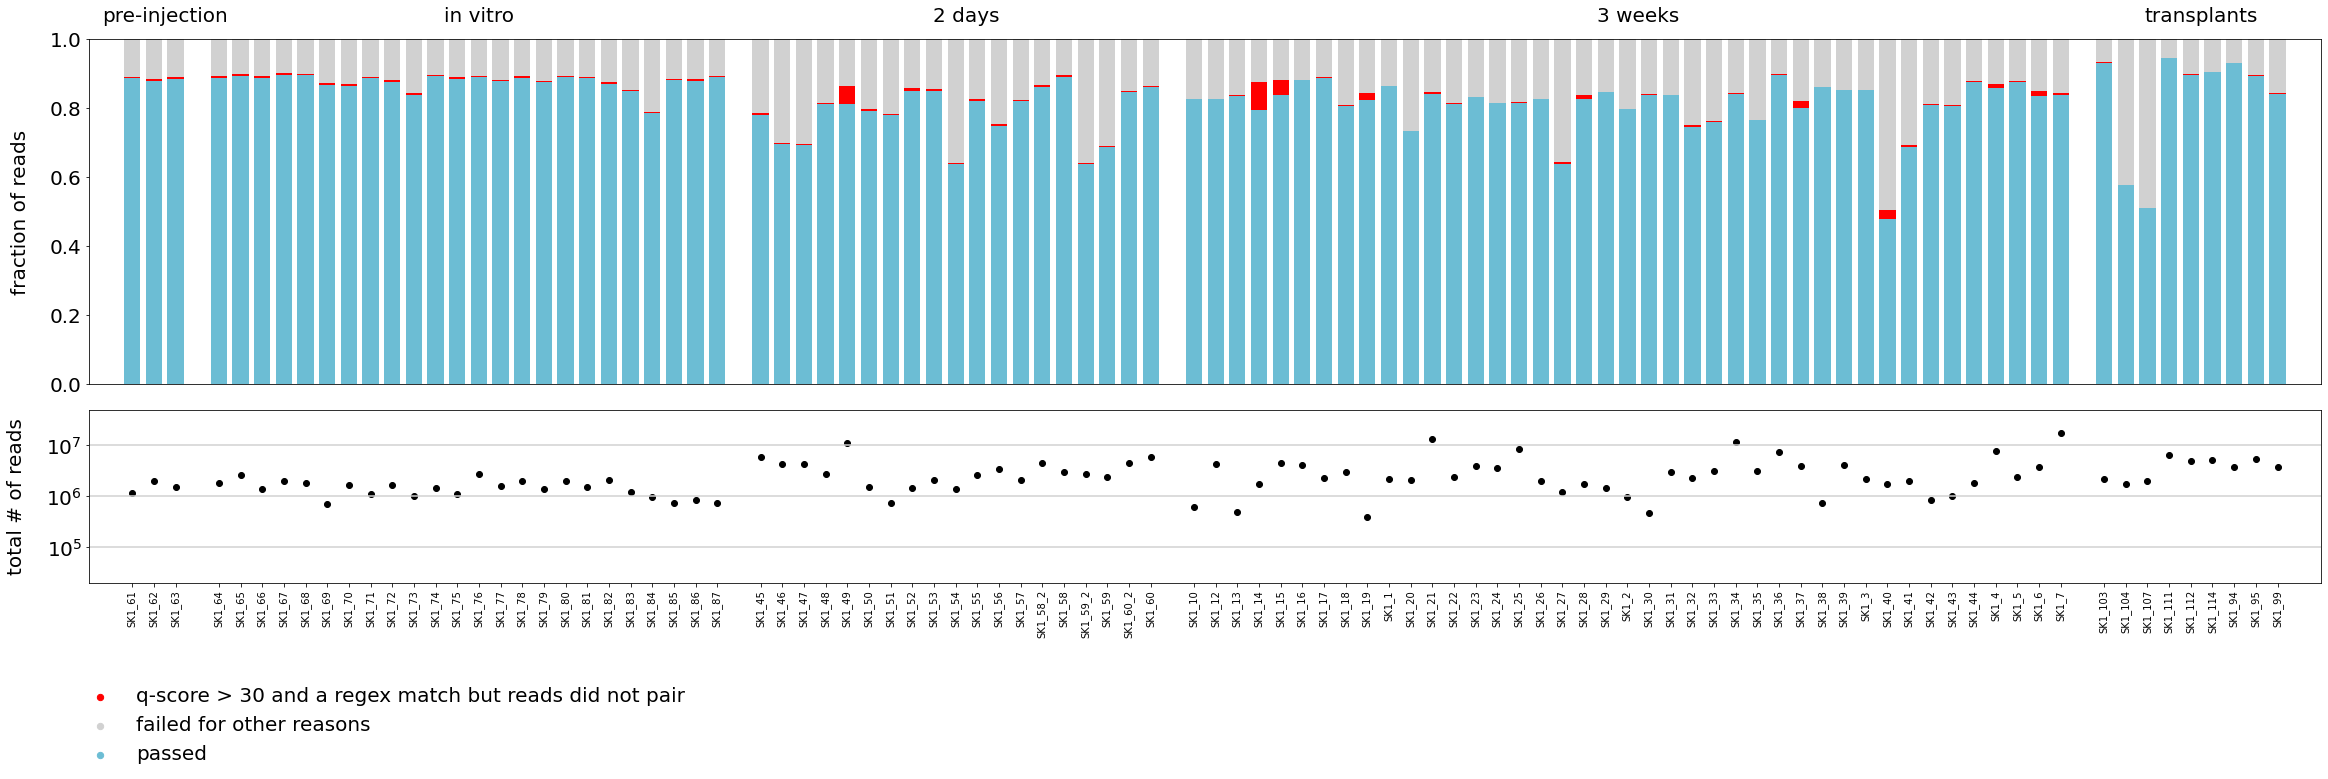

In [99]:
plt.figure(figsize=(40, 10))

grid = gridspec.GridSpec(ncols=1, nrows=2,
                         width_ratios=[1], wspace=0.2,
                         height_ratios=[2, 1], hspace=0.1)


plt.subplot(grid[0 // 1, 0 % 1])

plt.bar(range(0, len(samples_pre_inj)), 
        [x[-1] for x in stats if x[0] in samples_pre_inj], width=0.75, color='#6cbdd4')

plt.bar(range(0, len(samples_pre_inj)), 
        [x[-3] for x in stats if x[0] in samples_pre_inj], 
        bottom=[x[-1] for x in stats if x[0] in samples_pre_inj], width=0.75, color='red')

plt.bar(range(0, len(samples_pre_inj)), 
        [1 - x[-1] - x[-3] for x in stats if x[0] in samples_pre_inj], 
        bottom=[x[-1] + x[-3] for x in stats if x[0] in samples_pre_inj], width=0.75, color='#d1d1d1')
    

    
plt.bar(range(len(samples_pre_inj) + 1, len(samples_pre_inj) + len(samples_in_vitro) + 1), 
        [x[-1] for x in stats if x[0] in samples_in_vitro], width=0.75, color='#6cbdd4')

plt.bar(range(len(samples_pre_inj) + 1, len(samples_pre_inj) + len(samples_in_vitro) + 1), 
        [x[-3] for x in stats if x[0] in samples_in_vitro], 
        bottom=[x[-1] for x in stats if x[0] in samples_in_vitro], width=0.75, color='red')

plt.bar(range(len(samples_pre_inj) + 1, len(samples_pre_inj) + len(samples_in_vitro) + 1), 
        [1 - x[-1] - x[-3] for x in stats if x[0] in samples_in_vitro], 
        bottom=[x[-1] + x[-3] for x in stats if x[0] in samples_in_vitro], width=0.75, color='#d1d1d1')


    
plt.bar(range(len(samples_pre_inj) + len(samples_in_vitro) + 2, len(samples_pre_inj) + len(samples_in_vitro) + len(samples_2d) + 2), 
        [x[-1] for x in stats if x[0] in samples_2d], width=0.75, color='#6cbdd4')

plt.bar(range(len(samples_pre_inj) + len(samples_in_vitro) + 2, len(samples_pre_inj) + len(samples_in_vitro) + len(samples_2d) + 2), 
        [x[-3] for x in stats if x[0] in samples_2d], 
        bottom=[x[-1] for x in stats if x[0] in samples_2d], width=0.75, color='red')

plt.bar(range(len(samples_pre_inj) + len(samples_in_vitro) + 2, len(samples_pre_inj) + len(samples_in_vitro) + len(samples_2d) + 2), 
        [1 - x[-1] - x[-3] for x in stats if x[0] in samples_2d], 
        bottom=[x[-1] + x[-3] for x in stats if x[0] in samples_2d], width=0.75, color='#d1d1d1')



plt.bar(range(len(samples_pre_inj) + len(samples_in_vitro) + len(samples_2d) + 3, len(samples_pre_inj) + len(samples_in_vitro) + len(samples_2d) + len(samples_3w) + 3), 
        [x[-1] for x in stats if x[0] in samples_3w], width=0.75, color='#6cbdd4')

plt.bar(range(len(samples_pre_inj) + len(samples_in_vitro) + len(samples_2d) + 3, len(samples_pre_inj) + len(samples_in_vitro) + len(samples_2d) + len(samples_3w) + 3), 
        [x[-3] for x in stats if x[0] in samples_3w], 
        bottom=[x[-1] for x in stats if x[0] in samples_3w], width=0.75, color='red')

plt.bar(range(len(samples_pre_inj) + len(samples_in_vitro) + len(samples_2d) + 3, len(samples_pre_inj) + len(samples_in_vitro) + len(samples_2d) + len(samples_3w) + 3), 
        [1 - x[-1] - x[-3] for x in stats if x[0] in samples_3w], 
        bottom=[x[-1] + x[-3] for x in stats if x[0] in samples_3w],
        width=0.75, color='#d1d1d1')



plt.bar(range(len(samples_pre_inj) + len(samples_in_vitro) + len(samples_2d) + len(samples_3w) + 4, len(samples_pre_inj) + len(samples_in_vitro) + len(samples_2d) + len(samples_3w) + len(samples_transplant) + 4), 
        [x[-1] for x in stats if x[0] in samples_transplant], width=0.75, color='#6cbdd4')

plt.bar(range(len(samples_pre_inj) + len(samples_in_vitro) + len(samples_2d) + len(samples_3w) + 4, len(samples_pre_inj) + len(samples_in_vitro) + len(samples_2d) + len(samples_3w) + len(samples_transplant) + 4), 
        [x[-3] for x in stats if x[0] in samples_transplant], 
        bottom=[x[-1] for x in stats if x[0] in samples_transplant], width=0.75, color='red')

plt.bar(range(len(samples_pre_inj) + len(samples_in_vitro) + len(samples_2d) + len(samples_3w) + 4, len(samples_pre_inj) + len(samples_in_vitro) + len(samples_2d) + len(samples_3w) + len(samples_transplant) + 4), 
        [1 - x[-1] - x[-3] for x in stats if x[0] in samples_transplant], 
        bottom=[x[-1] + x[-3] for x in stats if x[0] in samples_transplant], width=0.75, color='#d1d1d1')

plt.ylim(0, 1)
plt.yticks([0, 0.2, 0.4, 0.6, 0.8, 1], size=20)

plt.xlim(-2, len(samples_pre_inj) + len(samples_in_vitro) + len(samples_2d) + len(samples_3w) + len(samples_transplant) + 5)
plt.xticks([], []);

plt.text(0.5 * len(samples_pre_inj), 1.05, 'pre-injection', size=20, ha='center')
plt.text(len(samples_pre_inj) + 1 + 0.5 * len(samples_in_vitro), 1.05, 'in vitro', size=20, ha='center')
plt.text(len(samples_pre_inj) + len(samples_in_vitro) + 2 + 0.5 * len(samples_2d), 1.05, '2 days', size=20, ha='center')
plt.text(len(samples_pre_inj) + len(samples_in_vitro) + len(samples_2d) + 3 + 0.5 * len(samples_3w), 1.05, '3 weeks', size=20, ha='center')
plt.text(len(samples_pre_inj) + len(samples_in_vitro) + len(samples_2d) + len(samples_3w) + 4 + 0.5 * len(samples_transplant), 1.05, 'transplants', size=20, ha='center')

plt.ylabel('fraction of reads', labelpad=20, fontsize=20)


plt.subplot(grid[1 // 1, 1 % 1])

plt.axhline(1e5, color='#d1d1d1')
plt.axhline(1e6, color='#d1d1d1')
plt.axhline(1e7, color='#d1d1d1')


plt.scatter(range(0, len(samples_pre_inj)),
            [x[1] for x in stats if x[0] in samples_pre_inj], color='black')

plt.scatter(range(len(samples_pre_inj) + 1, len(samples_pre_inj) + len(samples_in_vitro) + 1),
            [x[1] for x in stats if x[0] in samples_in_vitro], color='black')
  
plt.scatter(range(len(samples_pre_inj) + len(samples_in_vitro) + 2, len(samples_pre_inj) + len(samples_in_vitro) + len(samples_2d) + 2),
            [x[1] for x in stats if x[0] in samples_2d], color='black')
    
plt.scatter(range(len(samples_pre_inj) + len(samples_in_vitro) + len(samples_2d) + 3, len(samples_pre_inj) + len(samples_in_vitro) + len(samples_2d) + len(samples_3w) + 3), 
            [x[1] for x in stats if x[0] in samples_3w], color='black')

plt.scatter(range(len(samples_pre_inj) + len(samples_in_vitro) + len(samples_2d) + len(samples_3w) + 4, len(samples_pre_inj) + len(samples_in_vitro) + len(samples_2d) + len(samples_3w) + len(samples_transplant) + 4),
            [x[1] for x in stats if x[0] in samples_transplant], color='black')


'''
plt.scatter(range(0, len(samples_pre_inj)),
            [x[1] * x[-1] for x in stats if x[0] in samples_pre_inj], color='#6cbdd4')

plt.scatter(range(len(samples_pre_inj) + 1, len(samples_pre_inj) + len(samples_in_vitro) + 1),
            [x[1] * x[-1] for x in stats if x[0] in samples_in_vitro], color='#6cbdd4')
  
plt.scatter(range(len(samples_pre_inj) + len(samples_in_vitro) + 2, len(samples_pre_inj) + len(samples_in_vitro) + len(samples_2d) + 2),
            [x[1] * x[-1] for x in stats if x[0] in samples_2d], color='#6cbdd4')
    
plt.scatter(range(len(samples_pre_inj) + len(samples_in_vitro) + len(samples_2d) + 3, len(samples_pre_inj) + len(samples_in_vitro) + len(samples_2d) + len(samples_3w) + 3), 
            [x[1] * x[-1] for x in stats if x[0] in samples_3w], color='#6cbdd4')

plt.scatter(range(len(samples_pre_inj) + len(samples_in_vitro) + len(samples_2d) + len(samples_3w) + 4, len(samples_pre_inj) + len(samples_in_vitro) + len(samples_2d) + len(samples_3w) + len(samples_transplant) + 4),
            [x[1] * x[-1] for x in stats if x[0] in samples_transplant], color='#6cbdd4')
'''

plt.scatter(-10, 0, color='red', s=40, label='q-score > 30 and a regex match but reads did not pair')
plt.scatter(-10, 0, color='#d1d1d1',  s=40, label='failed for other reasons')
plt.scatter(-10, 0, color='#6cbdd4',  s=40, label='passed')

plt.yticks(size=20)
plt.ylim(2e4, 5e7);
plt.yscale('log'); plt.minorticks_off();


plt.xlim(-2, len(samples_pre_inj) + len(samples_in_vitro) + len(samples_2d) + len(samples_3w) + len(samples_transplant) + 5)
plt.xticks(list(range(len(samples_pre_inj))) + 
           list(range(len(samples_pre_inj) + 1, len(samples_pre_inj) + len(samples_in_vitro) + 1)) + 
           list(range(len(samples_pre_inj) + len(samples_in_vitro) + 2, len(samples_pre_inj) + len(samples_in_vitro) + len(samples_2d) + 2)) + 
           list(range(len(samples_pre_inj) + len(samples_in_vitro) + len(samples_2d) + 3, len(samples_pre_inj) + len(samples_in_vitro) + len(samples_2d) + len(samples_3w) + 3)) + 
           list(range(len(samples_pre_inj) + len(samples_in_vitro) + len(samples_2d) + len(samples_3w) + 4, len(samples_pre_inj) + len(samples_in_vitro) + len(samples_2d) + len(samples_3w) + len(samples_transplant) + 4)),
           [x[0] for x in stats if x[0] in samples_pre_inj] +
           [x[0] for x in stats if x[0] in samples_in_vitro] + 
           [x[0] for x in stats if x[0] in samples_2d] +
           [x[0] for x in stats if x[0] in samples_3w] +
           [x[0] for x in stats if x[0] in samples_transplant],
           rotation=90);

plt.ylabel('total # of reads', labelpad=20, fontsize=20)

plt.legend(frameon=False, ncol=1, bbox_to_anchor=(0.275, -0.5), fontsize=20);

# plt.savefig('../Data/cell-line-level/reads_stats.png', dpi=300, bbox_inches='tight')    
